Part A : Analyzing audio signal and downsampling

In [2]:
# Switch to your virtual environment
# Read the wav file “human_voice.wav” and write down its original sampling frequency.

import wave
wav_file = wave.open('human_voice.wav', 'r')
original_sampling_frequency = wav_file.getframerate()
print(f'Original Sampling Frequency: {original_sampling_frequency} Hz')


Original Sampling Frequency: 48000 Hz


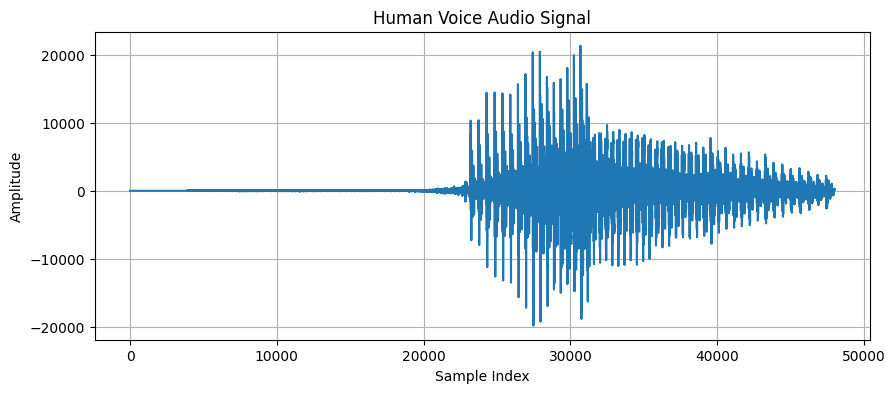

Number of samples after downsampling: 8000


In [3]:
# Plot the signal using matplotlib.

import matplotlib.pyplot as plt
import numpy as np
audio_data = wav_file.readframes(original_sampling_frequency)
audio_data = np.frombuffer(audio_data, dtype=np.int16)
# Plot the audio signal
plt.figure(figsize=(10, 4))
plt.plot(audio_data)
plt.title('Human Voice Audio Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid()
plt.show()


# Downsample the audio file to 8kHz without using inbuilt functions.

downsampled_frequency = 8000
downsampling_factor = original_sampling_frequency // downsampled_frequency
# Create downsampled audio data by taking every 6th sample
downsampled_audio_data = audio_data[::downsampling_factor]


# How many audio samples were obtained after downsampling?

print(f'Number of samples after downsampling: {len(downsampled_audio_data)}')

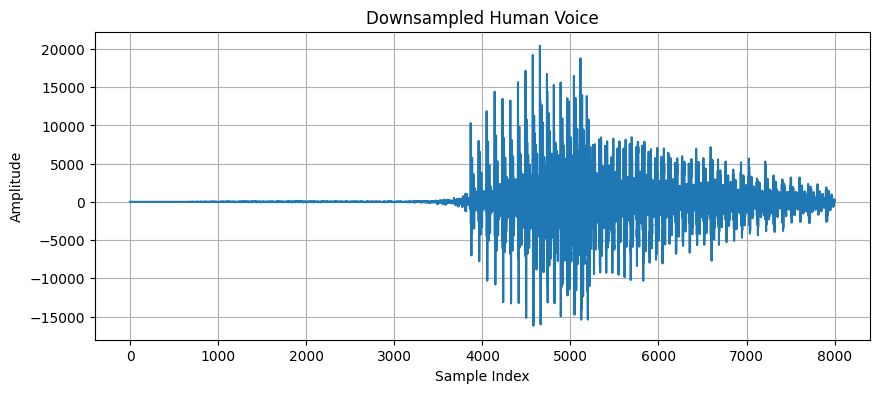

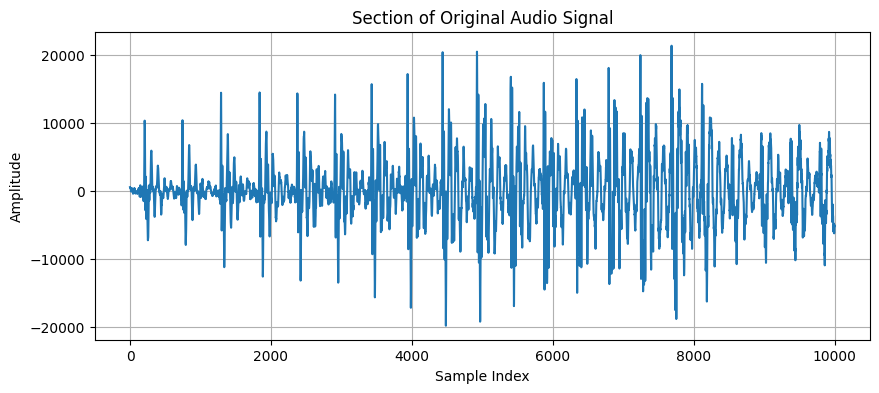

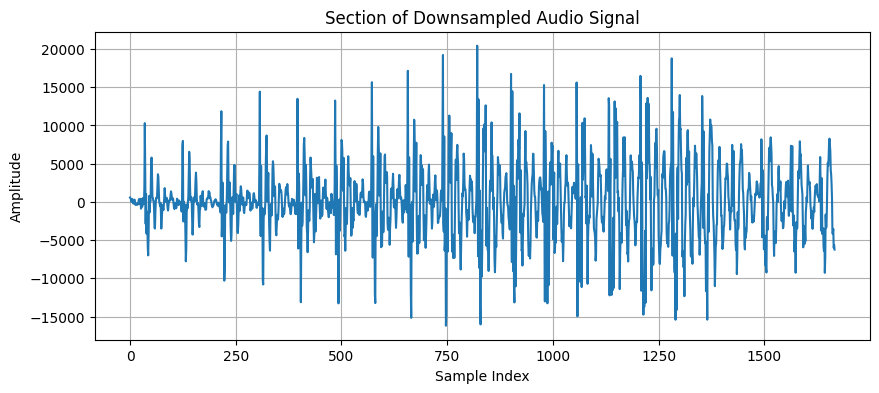

In [4]:
# Plot the downsampled signal using matplotlib.

plt.figure(figsize=(10, 4))
plt.plot(downsampled_audio_data)
plt.title('Downsampled Human Voice')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

# Observe a section of the audio signal corresponding to the same time period
# (hint: think of the sampling ratio and select two starting and ending points). What differences do you notice?
start_point = 23000
end_point = 33000
plt.figure(figsize=(10, 4))
plt.plot(audio_data[start_point:end_point])
plt.title('Section of Original Audio Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(downsampled_audio_data[(start_point//downsampling_factor):(end_point//downsampling_factor)])
plt.title('Section of Downsampled Audio Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

Part B: RMS, Cross-correlation, Sound Localization

In [5]:
# The microphones sample audio waves at 8 kHz.
# Calculate the rms values for each of the audio signals M1.wav, M2.wav and M3.wav using
# Python. (Here M1.wav is the audio signal received by the microphone M1)

import wave
import numpy as np

def calculate_rms(file_name):
    with wave.open(file_name, 'r') as wav_file:
        audio_data = wav_file.readframes(wav_file.getnframes())
        audio_data = np.frombuffer(audio_data, dtype=np.int16)
        
        #audio_data = audio_data.astype(np.float64) # Regular
        audio_data = audio_data.astype(np.float64) / 32768.0 # Normalized to [-1, 1]
        
        rms_value = np.sqrt(np.mean(audio_data**2))
        
    return rms_value

rms_M1 = calculate_rms('M1.wav')
rms_M2 = calculate_rms('M2.wav')
rms_M3 = calculate_rms('M3.wav')
print(f'RMS value for M1.wav: {rms_M1}')
print(f'RMS value for M2.wav: {rms_M2}')
print(f'RMS value for M3.wav: {rms_M3}')


RMS value for M1.wav: 0.2226534371816075
RMS value for M2.wav: 0.17811093522020563
RMS value for M3.wav: 0.22264741629107543


In [6]:
# Which microphone is the sound source closer to considering the rms value of M1 and M2?
if rms_M1 > rms_M2:
    print("The sound source is closer to microphone M1.")
else:
    print("The sound source is closer to microphone M2.")  

The sound source is closer to microphone M1.


In [7]:
# Using the cross correlation equation given: [m] = sum n=-inf to inf (x[n] * y[n+m])
# Calculate the time delay between 𝑅𝑥𝑦, the audio signals received by M1 and M2 using Python.
# Try to compute this without the use of inbuilt functions
import numpy as np
import wave

def cross_correlation(x, y, max_lag):
    correlation = np.zeros(2 * max_lag + 1)
    
    for m in range(-max_lag, max_lag + 1):
        sum_value = 0.0   # float accumulator
        
        for n in range(len(x)):
            if 0 <= n + m < len(y):
                sum_value += x[n] * y[n + m]
        
        correlation[m + max_lag] = sum_value
    
    return correlation


# --- Load audio files ---
with wave.open('M1.wav', 'r') as wav_file:
    audio_data_M1 = wav_file.readframes(wav_file.getnframes())
    audio_data_M1 = np.frombuffer(audio_data_M1, dtype=np.int16).astype(np.float64)

with wave.open('M2.wav', 'r') as wav_file:
    audio_data_M2 = wav_file.readframes(wav_file.getnframes())
    audio_data_M2 = np.frombuffer(audio_data_M2, dtype=np.int16).astype(np.float64)


# Set realistic maximum lag
max_lag = 50   # +/- 50 samples (~6.25 ms at 8 kHz ~2.14 meters between microphones)

correlation = cross_correlation(audio_data_M1, audio_data_M2, max_lag)

# Find delay
fs = 8000  # Sampling frequency
time_delay_samples = np.argmax(correlation) - max_lag # Adjust for zero-based index in correlation array
time_delay_seconds = time_delay_samples / fs

print(f"Time delay: {time_delay_samples} samples")
print(f"Time delay: {time_delay_seconds} seconds")

Time delay: 4 samples
Time delay: 0.0005 seconds


In [8]:
#Robot with two microphones M1 and M2 (M1 is on the robot's left and M2 is on it's right). S is the sound
#source emitting the signal. d1 is the distance between the sound source and M1, and d2 is the
#distance between the sound source and M2. Calculate the angle θ which the robot must turn to
#correct its heading toward the sound source. Let r, the radius of the robot, be 10cm (M1 = 10cm, M2 = 10cm)

# Given values
r = 10  # radius in cm
L = 2 * r  # distance between microphones
speed_of_sound = 34300  # speed of sound in cm/s
delta_d = speed_of_sound * abs(time_delay_seconds)

delta_d = np.clip(delta_d, -L, L)

theta_rad = np.arcsin(delta_d / L)
theta_deg = np.degrees(theta_rad)

if rms_M1 > rms_M2:
    print(f"Angle θ: {theta_deg} degrees left")
else:
    print(f"Angle θ: {theta_deg} degrees right")  

Angle θ: 59.03703129067231 degrees left


Part C: Frequency spectrum

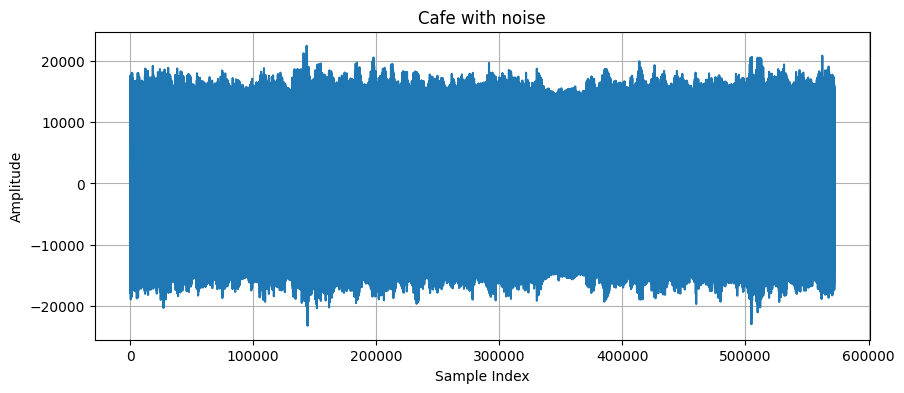

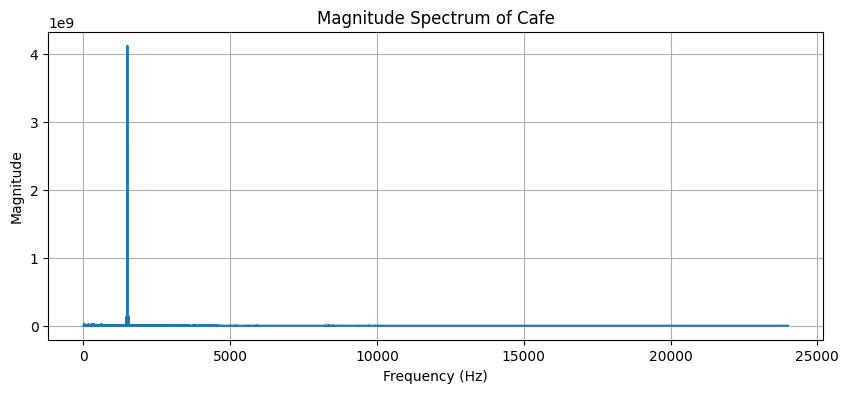

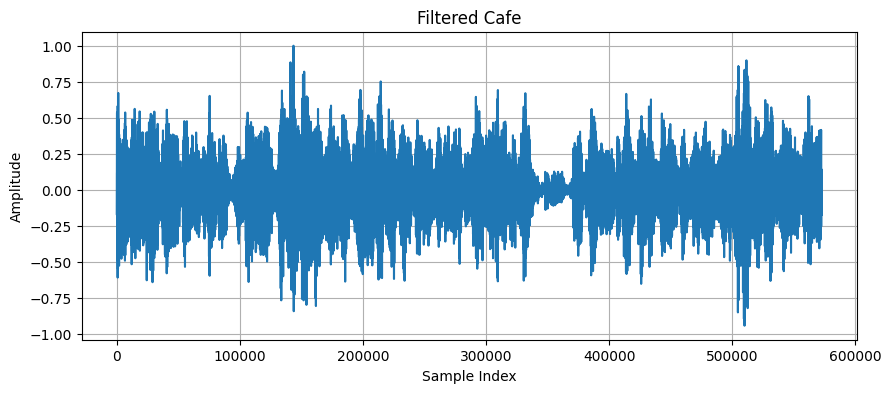

In [ ]:
# Plot the audio signal “Cafe_with_noise.wav” using matplotlib.
import matplotlib.pyplot as plt
import wave
import numpy as np

with wave.open('Cafe_with_noise.wav', 'r') as wav_file:
    audio_data = wav_file.readframes(wav_file.getnframes())
    audio_data = np.frombuffer(audio_data, dtype=np.int16).astype(np.float64)
    fs = wav_file.getframerate()

plt.figure(figsize=(10, 4))
plt.plot(audio_data)
plt.title('Cafe with noise')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid()
plt.show()


#Analyze the signal in the frequency domain to separate regions of human voice to noise.
# Compute the FFT of the audio signal
fft_result = np.fft.fft(audio_data)
frequencies = np.fft.fftfreq(len(audio_data), d=1/fs)
# Plot the magnitude spectrum
plt.figure(figsize=(10, 4))
plt.plot(frequencies[:len(frequencies)//2], np.abs(fft_result[:len(frequencies)//2]))
plt.title('Magnitude Spectrum of Cafe')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid()
plt.show()


#Implement a low pass filter to remove the noise and obtain only the voice signal.

def ideal_lowpass(signal, cutoff_freq, fs):
    N = len(signal)
    fft_signal = np.fft.fft(signal)
    freqs = np.fft.fftfreq(N, 1/fs)
    
    # Zero out frequencies above cutoff
    fft_signal[np.abs(freqs) > cutoff_freq] = 0
    
    filtered_signal = np.fft.ifft(fft_signal)
    
    return np.real(filtered_signal)

cutoff_frequency = 1450  #Hz
filtered_audio_data = ideal_lowpass(audio_data, cutoff_frequency, fs)

# Normalize
filtered_audio_data /= np.max(np.abs(filtered_audio_data))

# Plot the filtered audio signal
plt.figure(figsize=(10, 4))
plt.plot(filtered_audio_data)
plt.title('Filtered Cafe')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

#Play the filtered audio

#import sounddevice as sd
#sd.play(filtered_audio_data, fs)   # Uncomment both lines to play audio

